### Import the necessary libraries

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [3]:
heart_df = pd.read_csv('heart_disease_data.csv')
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Getting the statistical summary of the data

In [4]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


There are no missing values in the data set. Also, there are 303 rows of data and 14 columns.

In [5]:
heart_df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Exploratory Data Analysis

#### Age Distribution

<Figure size 700x700 with 0 Axes>

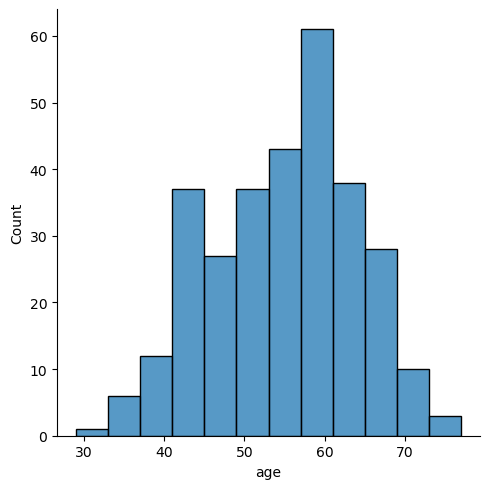

In [8]:
plt.figure(figsize = (7, 7))
sns.displot(heart_df, x='age')
plt.show()

#### Undertanding the distribution of the target column

From the chart above, majority of the patients are mostly beet 50+ to 60 years in age.

<Axes: xlabel='target', ylabel='count'>

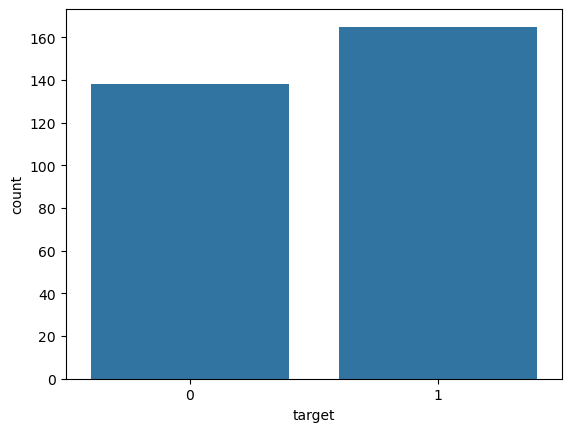

In [9]:
sns.countplot(heart_df, x = 'target')

From the chart above, approx. 140 patients do not have any heart defect while about 160+ patients have heart defect. Also, the ratio of no heart defect to heart defect is almost the same. 

#### Distribution of the Sex Column

<Axes: xlabel='sex', ylabel='count'>

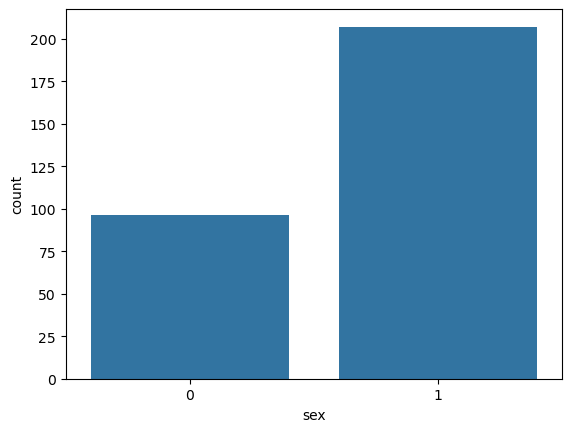

In [10]:
sns.countplot(heart_df, x = 'sex')

0 --> Female [almost 100], 1---> Male [more than 200]

### Splitting the data

In [12]:
# Features
X = heart_df.drop('target', axis = 1).values

# Target
y = heart_df['target'].values

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

In [17]:
print(X.shape, X_train.shape, X_test.shape)

(303, 13) (242, 13) (61, 13)


### Build the Logistic Regression Model

In [40]:
# Create an instance of the model
log_model = LogisticRegression()

In [41]:
# Fit the model
log_model.fit(X_train, y_train)

C:\Users\Itz_Ebuka\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [42]:
# Evaluate the model performance on te training set
print('Training Accuracy: ', log_model.score(X_train, y_train))

Training Accuracy:  0.8388429752066116


The Model accuracy on the test set is 83.88%. 

In [43]:
# Using this on the test set
test_pred = log_model.predict(X_test)

In [44]:
# Evaluate the model performance
print('Test Accuracy: ', classification_report(y_test, test_pred))

Test Accuracy:                precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



The Model accuracy on the test set is 80%.

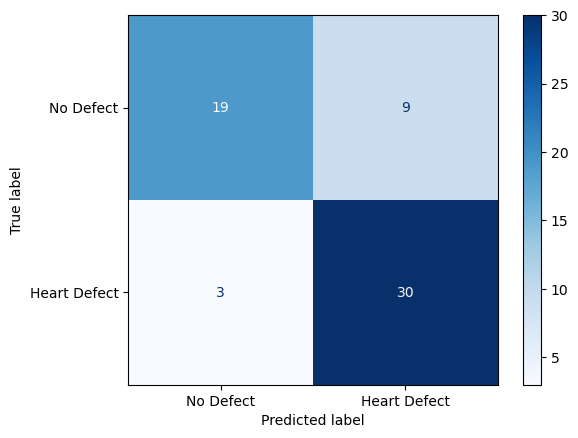

In [46]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels = ['No Defect', 'Heart Defect'],
    cmap = plt.cm.Blues
)

plt.show()